[0.5 0.5]


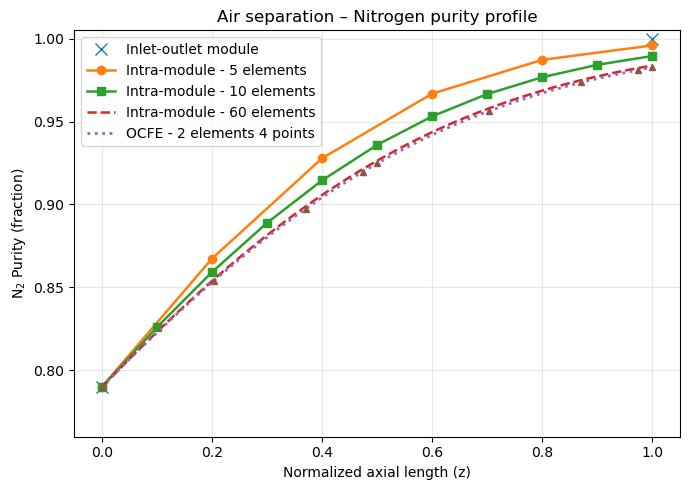

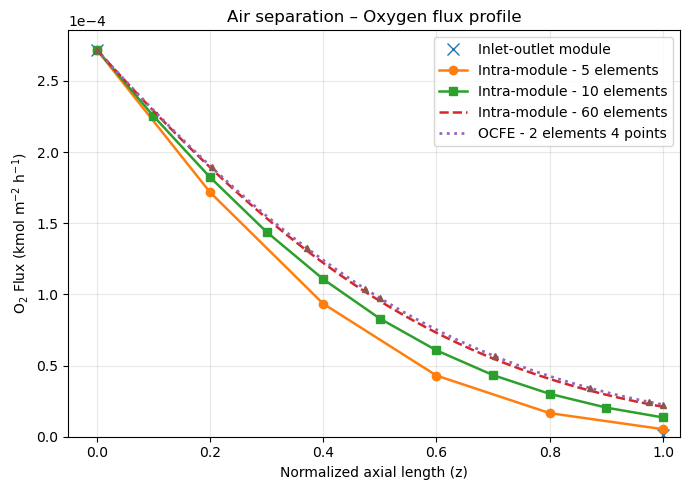


Final values:
  FE-5 final N2 purity:         0.995919
  FE-10 final N2 purity:        0.989545
  FE-60 final N2 purity:        0.983767
  OCFE final N2 purity:         0.982623


In [2]:
# OCFE Modeling for Air Separation Case Study
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
%matplotlib inline

# The variable definition
#   F_i^R : retentate-side component flowrate of species i
#   F_i^S : permeate-side component flowrate of species i
#   x_i^R : retentate-side mole fraction of species i
#   x_i^S : permeate-side mole fraction of species i
#   p_i^R = x_i^R * P^R : retentate-side partial pressure of species i
#   p_i^S = x_i^S * P^S : permeate-side partial pressure of species i
#   J_i   = Pi_i * (p_i^R - p_i^S) : local molar flux of species i

# The OCFE residual:
#   (1 / h_l) * sum_k D_{j,k} * F_i^R(s_{l,k}) + A_m * J_i(s_{l,j}) = 0
#   (1 / h_l) * sum_k D_{j,k} * F_i^S(s_{l,k}) - A_m * J_i(s_{l,j}) = 0


def GPU_to_kmol_m2_h_bar(GPU):
    """
    Convert permeance from GPU to kmol m^-2 h^-1 bar^-1.

        1 GPU = 3.348e-10 mol m^-2 s^-1 Pa^-1

    Convertion:
      mol to kmol     by dividing by 1000
      s   to h        by multiplying by 3600
      Pa  to bar      by multiplying by 1.0e5
        Permeance in kmol m^-2 h^-1 bar^-1.
    """
    # Multiply the given GPU value by the full unit-conversion factor.
    return GPU * 3.348e-10 * 1.0e5 * 3600.0 / 1e3


def lagrange_basis_weights(s_nodes, s_eval):
    """
    Compute the Lagrange interpolation weights W_j(s_eval),
    where a variable inside one finite element is approximated by
    a polynomial passing through values at the collocation nodes.

    Parameters:
    s_nodes : array-like
        The interpolation/collocation nodes inside one finite element.
    s_eval : float
        The local coordinate s at which we want to evaluate the interpolating polynomial.

    Returns:
    W : numpy.ndarray
        Array of weights W_j(s_eval), one for each node j.
    """
    # Convert the node list to a NumPy array of floating-point values.
    s_nodes = np.asarray(s_nodes, dtype=float)

    # Start with an array of ones because each Lagrange basis polynomial
    # is a product of several factors multiplied together.
    W = np.ones(len(s_nodes), dtype=float)

    # Loop over each basis polynomial index j.
    for j in range(len(s_nodes)):
        # For basis polynomial j, multiply over all other node indices k != j.
        for k in range(len(s_nodes)):
            # Skip the term where k == j because that factor is not included in the product.
            if k != j:
                # Multiply by the standard Lagrange factor:
                # (s_eval - s_k) / (s_j - s_k)
                W[j] *= (s_eval - s_nodes[k]) / (s_nodes[j] - s_nodes[k])

    # Return the full vector of interpolation weights.
    return W

def lagrange_derivative_matrix(s_nodes):
    """
    Construct the derivative matrix D for Lagrange collocation.

    We need the derivative matrix to turn differential equations into algebraic equations that the solver can solve.
    Suppose one element has 3 nodes: s = [0, 0.5, 1], flow values = [10, 7, 4], devivative matrix, D = [-3 4 -1, -1 0 1, 1 -4 3],
    then the derivative at the middle node is dF/ds at 0.5 is -1(10)+0(7)+1(4)=-6.

    In OCFE, we start with a differential equation (dF/dz) but a solver cannot directly handle the dF/dz. Derivative matrix converts
    dF/dz into algebric equations which solver can solve easily. dF/dz = summation (Dj,k * Fk) = flux term
    Parameters:
    s_nodes : array-like
        Local collocation/interpolation nodes inside one finite element.

    Returns:
    D : numpy.ndarray
        The derivative matrix D_{i,j}.
    """
    # Convert the node list into a NumPy float array for safe numerical use.
    s_nodes = np.asarray(s_nodes, dtype=float)

    # Store the number of nodes.
    n = len(s_nodes)

    # Initialize the weights array with ones.
    # These weights help construct the derivative matrix efficiently and accurately.
    bary = np.ones(n, dtype=float)
    # Loop over node index j to compute each weight.
    for j in range(n):
        # For each node j, loop over all other nodes k.
        for k in range(n):
            # Exclude the self-term because the product is only over k != j.
            if k != j:
                # Divide bary[j] by (s_j - s_k), building the product-form denominator.
                bary[j] /= (s_nodes[j] - s_nodes[k])

    # Initialize the derivative matrix D as an n by n zero matrix.
    D = np.zeros((n, n), dtype=float)

    # Loop over row index i, which corresponds to the point where the derivative is evaluated.
    for i in range(n):
        # Loop over column index j, which corresponds to the basis function being differentiated.
        for j in range(n):
            # Off-diagonal entries follow the differentiation formula.
            if i != j:
                # Compute D[i,j] from weights and node spacing.
                D[i, j] = bary[j] / (bary[i] * (s_nodes[i] - s_nodes[j]))
        # Set the diagonal entry so that each row sums to zero.
        # This is the standard and numerically stable way to complete D.
        D[i, i] = -np.sum(D[i, :])

    # Return the completed derivative matrix.
    return D


def composition(F):
    """
    Compute species mole fractions and total flowrate from component flowrates.
    """
    # Sum the component flowrates to obtain the total flowrate.
    F_total = sum(F.values())
    # If the total flow is zero or negative, avoid division by zero.
    # In that case, return equal mole fractions as a safe fallback
    if F_total <= 0.0:
        # Count how many species appear in the dictionary.
        n = len(F)
        # Return equal fractions for all species and zero total flow.
        return {i: 1.0 / n for i in F}, 0.0
    # Otherwise, return the normal mole fraction definition x_i = F_i / F_total.
    return {i: F[i] / F_total for i in F}, F_total


def local_flux(F_R, F_S, P_R, P_S, Pi):
    """
    Compute the local gas-separation fluxes.

    For gas separation:
        J_i = Pi_i * (p_i^R - p_i^S)

    with:
        p_i^R = x_i^R * P^R
        p_i^S = x_i^S * P^S

    Parameters:
    F_R : dict
        Retentate-side component flowrates.
    F_S : dict
        Permeate-side component flowrates.
    P_R : float
        Retentate-side pressure in bar.
    P_S : float
        Permeate-side pressure in bar.
    Pi : dict
        Species permeances.

    Returns:
    J : dict
        Local species fluxes.
    x_R : dict
        Retentate-side mole fractions.
    x_S : dict
        Permeate-side mole fractions.
    p_R : dict
        Retentate-side partial pressures.
    p_S : dict
        Permeate-side partial pressures.
    """
    # Compute retentate-side composition and retentate-side total flowrate.
    x_R, F_R_total = composition(F_R)

    # Compute permeate-side composition and permeate-side total flowrate.
    x_S, F_S_total = composition(F_S)

    # Compute retentate-side partial pressures p_i^R = x_i^R * P^R.
    p_R = {i: x_R[i] * P_R for i in F_R}

    # If permeate-side total flow is extremely small, set permeate-side partial pressures to zero.
    if F_S_total <= 1.0e-14:
        # Set all permeate-side partial pressures to zero.
        p_S = {i: 0.0 for i in F_S}
    else:
        # Otherwise compute p_i^S = x_i^S * P^S normally.
        p_S = {i: x_S[i] * P_S for i in F_S}

    # Compute the local species fluxes using the gas-separation flux law.
    # The max(..., 0.0) prevents negative flux in case a local driving force becomes negative numerically.
    #J = {i: max(Pi[i] * (p_R[i] - p_S[i]), 0.0) for i in F_R} # We can use this expression
    J = {i:(Pi[i] * (p_R[i] - p_S[i])) for i in F_R} # We can also use this expression. If zero flux happens, it will be reflected in figure plotting.
    # Return the full set of local quantities.
    return J, x_R, x_S, p_R, p_S


def make_air_separation_parameters(permeance_mode="effective"):
    """
    Build and return the base parameter set.

    Modes:
    permeance_mode = "effective"
        Uses effective permeances chosen.

    permeance_mode = "gpu"
        Uses literal conversion of 1600 GPU for O2 and 160 GPU for N2.

    Returns:
    params : dict
        Dictionary containing all required parameters.
    """
    # Define the species list used in this air-separation problem.
    species = ["N2", "O2"]

    # Define the inlet retentate-side feed flowrates.
    F_RI = {"N2": 2.300 * 0.79, "O2": 2.300 * 0.21}

    # Define the inlet permeate-side flowrates.
    # No sweep gas.
    F_SI = {"N2": 0.0, "O2": 0.0}

    # Set the retentate-side pressure in bar.
    P_R = 10.0

    # Set the permeate-side pressure in bar.
    P_S = 0.0

    # Set the total membrane length.
    L_m = 20.0

    # Choose either permeance or gpu mode.
    if permeance_mode == "effective":
        # Use effective permeance values in kmol m^-2 h^-1 bar^-1.
        Pi = {"O2": 1.2954e-4, "N2": 1.2954e-5}

        # Total membrane area.
        A_m = 4e3

    elif permeance_mode == "gpu":
        # Use literal GPU-based permeance conversion for O2 and N2.
        Pi = {
            "O2": GPU_to_kmol_m2_h_bar(1600.0),
            "N2": GPU_to_kmol_m2_h_bar(160.0),
        }

        # membrane area.
        A_m = 4e3

        # Permeate pressure
        P_S = 1.0

    else:
        raise ValueError

    # Return all parameters in one dictionary so downstream functions can use them cleanly.
    return {
        "species": species,
        "F_RI": F_RI,
        "F_SI": F_SI,
        "P_R": P_R,
        "P_S": P_S,
        "Pi": Pi,
        "A_m": A_m,
        "L_m": L_m,
    }


def simulate_inlet_outlet(params):
    """
    Simulate the inlet-outlet model.

    This model does not resolve spatial variation.
    It uses inlet conditions to compute one constant driving force
    for the entire membrane module.

    Balances:
        F_i^RI - F_i^RO - J_i * A_m = 0
        F_i^SI - F_i^SO + J_i * A_m = 0
    """
    # Read the species list from the parameter dictionary.
    species = params["species"]

    # Read the retentate-side inlet flowrates.
    F_RI = params["F_RI"]

    # Read the permeate-side inlet flowrates.
    F_SI = params["F_SI"]

    # Read the retentate-side pressure.
    P_R = params["P_R"]

    # Read the permeate-side pressure.
    P_S = params["P_S"]

    # Read the permeance dictionary.
    Pi = params["Pi"]

    # Read the total membrane area.
    A_m = params["A_m"]

    # Compute the lumped-model inlet flux from inlet conditions.
    J_in, x_RI, _, _, _ = local_flux(F_RI, F_SI, P_R, P_S, Pi)

    # Compute outlet retentate flowrates using the inlet-outlet balance.
    F_RO = {i: max(F_RI[i] - J_in[i] * A_m, 0.0) for i in species}

    # Compute outlet permeate flowrates using the inlet-outlet balance.
    F_SO = {i: F_SI[i] + J_in[i] * A_m for i in species}

    # Compute outlet retentate composition.
    x_RO, _ = composition(F_RO)

    # Outlet oxygen flux tends to zero.
    J_O2_outlet_plot = 1.0e-6

    # Return all quantities in a dictionary.
    return {
        # z-coordinates for inlet and outlet of the module.
        "z": np.array([0.0, 1.0]),

        # Nitrogen purity on the retentate side at inlet and outlet.
        "x_R_N2": np.array([x_RI["N2"], x_RO["N2"]]),

        # O2 flux plotting points for the inlet-outlet model.
        "J_O2_plot": np.array([J_in["O2"], J_O2_outlet_plot]),

        # Store the actual constant lumped-model O2 flux as well in case we want it later.
        "J_O2_constant": J_in["O2"],

        # Store retentate-side states.
        "F_R": [F_RI, F_RO],

        # Store permeate-side states.
        "F_S": [F_SI, F_SO],
    }


def simulate_finite_elements(params, n_elements):
    """
    Simulate the discretized intra-module model.

    Idea:
    The membrane is divided into n_elements equal finite elements.
    Each element behaves like a small staged module.

    On each element:
        F_i^R,out = F_i^R,in - J_i * DeltaA
        F_i^S,out = F_i^S,in + J_i * DeltaA

    where the local flux J_i is evaluated from the current local inlet state.

    Parameters:
    params : dict
        Problem parameters.
    n_elements : int
        Number of equal finite elements.

    Returns:
    dict
        Arrays of z, nitrogen purity profile, and oxygen flux profile.
    """
    # Read the species list.
    species = params["species"]

    # Read the retentate-side pressure.
    P_R = params["P_R"]

    # Read the permeate-side pressure.
    P_S = params["P_S"]

    # Read the permeance dictionary.
    Pi = params["Pi"]

    # Read the total membrane area.
    A_m = params["A_m"]

    # Compute the area per finite element.
    DeltaA = A_m / n_elements

    # Initialize the current retentate-side state using the module inlet.
    F_R = {i: float(params["F_RI"][i]) for i in species}

    # Initialize the current permeate-side state using the module inlet.
    F_S = {i: float(params["F_SI"][i]) for i in species}

    # Start the z-coordinate list with the inlet point z = 0.
    z = [0.0]

    # Compute initial retentate composition.
    x_R, _ = composition(F_R)

    # Compute initial local flux.
    J, _, _, _, _ = local_flux(F_R, F_S, P_R, P_S, Pi)

    # Start the N2 purity profile with the inlet retentate composition.
    x_R_N2 = [x_R["N2"]]

    # Start the O2 flux profile with the inlet local O2 flux.
    J_O2 = [J["O2"]]

    # Loop over each finite element from 1 to n_elements inclusive.
    for e in range(1, n_elements + 1):
        # Compute the local flux at the beginning of the current element.
        J, _, _, _, _ = local_flux(F_R, F_S, P_R, P_S, Pi)

        # Loop over each species and apply the finite-element/staged update.
        for i in species:
            # Compute how much of species i permeates across this finite element area.
            dF = J[i] * DeltaA

            # Update the retentate-side flowrate by subtracting the permeated amount.
            F_R[i] = max(F_R[i] - dF, 0.0) # Retentate outlet of element 1 becomes the retentate inlet of element 2
            #F_R[i] = (F_R[i] - dF)

            # Update the permeate-side flowrate by adding the permeated amount.
            F_S[i] = F_S[i] + dF

        # Compute the updated retentate composition after the current element.
        x_R, _ = composition(F_R)

        # Compute the updated local flux after the current element.
        J_local, _, _, _, _ = local_flux(F_R, F_S, P_R, P_S, Pi)

        # Append the normalized axial position of the current element endpoint.
        z.append(e / n_elements)

        # Append the updated nitrogen purity.
        x_R_N2.append(x_R["N2"])

        # Append the updated oxygen flux.
        J_O2.append(J_local["O2"])

    # Return the complete finite-element results.
    return {
        "z": np.array(z),
        "x_R_N2": np.array(x_R_N2),
        "J_O2": np.array(J_O2),
    }


def solve_ocfe_element(F_R_in, F_S_in, h_l, s_nodes, params):
    """
    Solve one OCFE finite element using collocation equations.

    Parameters:
    F_R_in : dict
        Retentate-side inlet component flowrates for this finite element.
    F_S_in : dict
        Permeate-side inlet component flowrates for this finite element.
    h_l : float
        Size of the finite element in normalized coordinate z.
    s_nodes : numpy.ndarray
        Local collocation/interpolation nodes inside this finite element.
    params : dict
        Model parameters.

    Returns:
    V : dict
        Dictionary storing nodal values of retentate/permeate component flowrates.
        Keys are tuples like ("R","N2"), ("S","O2"), etc.
    """
    # Read the species list.
    species = params["species"]

    # Read retentate-side pressure.
    P_R = params["P_R"]

    # Read permeate-side pressure.
    P_S = params["P_S"]

    # Read permeances.
    Pi = params["Pi"]

    # Read total membrane area.
    A_m = params["A_m"]

    # Number of collocation points excluding the left boundary node.
    nc = len(s_nodes) - 1

    # Build the Lagrange derivative matrix for the given local nodes.
    D = lagrange_derivative_matrix(s_nodes)

    def unpack(y):
        """
        Convert the nonlinear solver vector y into a structured dictionary
        of nodal values for all component flowrates on both sides.
        """
        # Initialize an empty dictionary to store the reconstructed nodal values.
        V = {}

        # Initialize the running vector index.
        idx = 0

        # Loop over the two sides: retentate side "R" and permeate side "S".
        for side in ("R", "S"):
            # Loop over each species.
            for i in species:
                # Allocate an array of length nc+1 for the nodal values on this side/species.
                vals = np.empty(nc + 1)

                # Set the left boundary node value from the known inlet of the finite element.
                vals[0] = F_R_in[i] if side == "R" else F_S_in[i]

                # Fill the remaining nodes from the unknown vector y.
                vals[1:] = y[idx: idx + nc]

                # Advance the running index by nc entries.
                idx += nc

                # Store the full nodal array in the dictionary using key (side, species).
                V[(side, i)] = vals

        # Return the structured nodal-value dictionary.
        return V

    def residual(y):
        """
        Build the nonlinear residual vector for the OCFE collocation equations.
        """
        # Convert the solver vector into nodal flowrate arrays.
        V = unpack(y)

        # Start with an empty residual list.
        res = []

        # Loop over collocation nodes j = 1..nc.
        # Node j=0 is the left boundary node and is not a collocation equation.
        for j in range(1, nc + 1):
            # Build the retentate-side state at collocation node j.
            F_R_j = {i: V[("R", i)][j] for i in species}

            # Build the permeate-side state at collocation node j.
            F_S_j = {i: V[("S", i)][j] for i in species}

            # Compute local flux and compositions at collocation node j.
            J_j, _, _, _, _ = local_flux(F_R_j, F_S_j, P_R, P_S, Pi)

            # Loop over species to build the retentate and permeate residual equations.
            for i in species:
                # Compute the OCFE derivative approximation for retentate-side flow of species i.
                # This will give total 8 equations
                dF_R_ds = np.dot(D[j, :], V[("R", i)])

                # Compute the OCFE derivative approximation for permeate-side flow of species i.
                # This will give total 8 equations
                dF_S_ds = np.dot(D[j, :], V[("S", i)])

                # Append the retentate-side collocation residual:
                # (1/h_l) * dF_R/ds + A_m * J_i = 0
                res.append(dF_R_ds / h_l + A_m * J_j[i])

                # Append the permeate-side collocation residual:
                # (1/h_l) * dF_S/ds - A_m * J_i = 0
                res.append(dF_S_ds / h_l - A_m * J_j[i])

        # Convert the residual list to a NumPy array and return it.
        return np.array(res)

    # Compute the inlet local flux to build a reasonable initial guess for the nonlinear solve.
    J_in, _, _, _, _ = local_flux(F_R_in, F_S_in, P_R, P_S, Pi)

    # Start an empty list to assemble the initial guess vector y0.
    y0 = []

    # Loop over both sides.
    for side in ("R", "S"):
        # Use a negative sign for retentate since retentate decreases along the element.
        # Use a positive sign for permeate since permeate increases along the element.
        sign = -1.0 if side == "R" else 1.0

        # Loop over species.
        for i in species:
            # Set the base value at the element inlet.
            F0 = F_R_in[i] if side == "R" else F_S_in[i]

            # Loop over local nodes excluding the left boundary node.
            for s in s_nodes[1:]:
                # Add a simple linearized guess for the flow at local coordinate s.
                # max(...,1e-12) keeps all guesses strictly positive to help the solver.
                y0.append(max(F0 + sign * A_m * J_in[i] * h_l * s, 1.0e-12))

    # Solve the nonlinear collocation residual equations using SciPy's hybr method.
    sol = root(residual, np.array(y0), method="hybr")

    # Check whether the solver failed or the residual remains too large.
    if (not sol.success) or (np.max(np.abs(residual(sol.x))) > 1.0e-7):
        # Raise a runtime error if the OCFE solve did not converge properly.
        raise RuntimeError(f"OCFE solve failed: {sol.message}")

    # Return the solved nodal values in structured dictionary form.
    return unpack(sol.x)


def simulate_ocfe(params, n_elements=2, dense_points_per_element=120):
    """
    Simulate the OCFE-enhanced intra-module model.

    Setting:
    - 2 finite elements
    - 4 collocation points per element

    Implementation detail:
    We use one left boundary node plus 4 collocation nodes per element.
    Dense interpolation points are also generated for smooth plotting. We can also ignore this one.

    Parameters:
    params : dict
        Problem parameters.
    n_elements : int
        Number of finite elements; default is 2.
    dense_points_per_element : int
        Number of dense plotting points per element.

    Returns:
    dict
        Dense and nodal profiles for nitrogen purity and oxygen flux.
    """
    # Define the local OCFE nodes for one finite element.
    # This includes the left boundary node and four collocation nodes.
    #s_nodes = np.array([
    #    0.0,
    #   0.088587959512704,
    #    0.409466864440735,
    #    0.787659461760847,
    #    1.0,
    #], dtype=float)

    s_nodes = np.array([
        0.0,
        0.40585,
        0.74153,
        0.94911,
        1.0,
    ], dtype=float)

    # Read the species list.
    species = params["species"]

    # Read retentate-side pressure.
    P_R = params["P_R"]

    # Read permeate-side pressure.
    P_S = params["P_S"]

    # Read permeances.
    Pi = params["Pi"]

    # Build the vector of finite-element sizes.
    h = np.ones(n_elements, dtype=float) / n_elements
    print(h)

    # Set the inlet retentate-side flowrates for the first element.
    F_R_in = {i: float(params["F_RI"][i]) for i in species}

    # Set the inlet permeate-side flowrates for the first element.
    F_S_in = {i: float(params["F_SI"][i]) for i in species}

    # Initialize arrays for the collocation node coordinates.
    z_nodes = []

    # Initialize arrays for nitrogen purity evaluated at the collocation nodes.
    x_R_N2_nodes = []

    # Initialize arrays for oxygen flux evaluated at the collocation nodes.
    J_O2_nodes = []

    # Initialize arrays for smooth dense plotting coordinates.
    z_dense = []

    # Initialize arrays for dense nitrogen purity profile.
    x_R_N2_dense = []

    # Initialize arrays for dense oxygen flux profile.
    J_O2_dense = []

    # Initialize the global z-offset of the current element.
    z_offset = 0.0

    # Loop over each finite element.
    for l in range(n_elements):
        # Solve the OCFE equations for the current finite element.
        V = solve_ocfe_element(F_R_in, F_S_in, h[l], s_nodes, params)

        # Loop over the collocation/interpolation nodes in the current element.
        for j, s in enumerate(s_nodes):
            # Skip the left boundary node of all elements after the first
            # so repeated points are not plotted twice.
            if l > 0 and j == 0:
                continue

            # Build the retentate-side state at node j.
            F_R_j = {i: V[("R", i)][j] for i in species}

            # Build the permeate-side state at node j.
            F_S_j = {i: V[("S", i)][j] for i in species}

            # Compute local flux and retentate composition at node j.
            J_j, x_R_j, _, _, _ = local_flux(F_R_j, F_S_j, P_R, P_S, Pi)

            # Append the global normalized axial coordinate of this node.
            z_nodes.append(z_offset + h[l] * s)

            # Append the retentate-side nitrogen purity at this node.
            x_R_N2_nodes.append(x_R_j["N2"])

            # Append the local oxygen flux at this node.
            J_O2_nodes.append(J_j["O2"])

        # Build dense interpolation points inside the current element for smooth curve plotting.
        s_dense_local = np.linspace(0.0, 1.0, dense_points_per_element)

        # Loop over each dense interpolation point in the current element.
        for q, s_eval in enumerate(s_dense_local):
            # Skip the first dense point for elements after the first to avoid duplication at boundaries.
            if l > 0 and q == 0:
                continue

            # Compute interpolation weights at this local evaluation point.
            W = lagrange_basis_weights(s_nodes, s_eval)

            # Initialize dictionaries to store interpolated retentate and permeate states.
            F_R_eval = {}
            F_S_eval = {}

            # Loop over species and interpolate retentate/permeate flowrates.
            for i in species:
                # Interpolate retentate-side component flowrate using the Lagrange weights.
                F_R_eval[i] = float(np.dot(W, V[("R", i)]))

                # Interpolate permeate-side component flowrate using the Lagrange weights.
                F_S_eval[i] = float(np.dot(W, V[("S", i)]))

            # Compute local flux and retentate composition at this dense interpolation point.
            J_eval, x_R_eval, _, _, _ = local_flux(F_R_eval, F_S_eval, P_R, P_S, Pi)

            # Append the global normalized axial coordinate.
            z_dense.append(z_offset + h[l] * s_eval)

            # Append the dense retentate-side nitrogen purity.
            x_R_N2_dense.append(x_R_eval["N2"])

            # Append the dense oxygen flux.
            J_O2_dense.append(J_eval["O2"])

        # Compute the interpolation weights at the element endpoint s = 1.0.
        W_end = lagrange_basis_weights(s_nodes, 1.0)

        # Enforce continuity by using the element endpoint as the inlet to the next element.
        F_R_in = {i: float(np.dot(W_end, V[("R", i)])) for i in species}
        F_S_in = {i: float(np.dot(W_end, V[("S", i)])) for i in species}

        # Increase the element offset so the next element starts at the correct global z.
        z_offset += h[l]

    # Return dense and nodal profiles.
    return {
        "z_nodes": np.array(z_nodes),
        "x_R_N2_nodes": np.array(x_R_N2_nodes),
        "J_O2_nodes": np.array(J_O2_nodes),
        "z": np.array(z_dense),
        "x_R_N2": np.array(x_R_N2_dense),
        "J_O2": np.array(J_O2_dense),
    }


def plot_figure_6_and_7(permeance_mode="effective"):
    """
    Run all models and generate Figure 6 and Figure 7.
    """
    # Build the parameter set using the selected permeance mode.
    params = make_air_separation_parameters(permeance_mode=permeance_mode)

    # Run the inlet-outlet model.
    res_IO = simulate_inlet_outlet(params)

    # Run the uniform finite-element model with 5 elements.
    res_FE_5 = simulate_finite_elements(params, 5)

    # Run the uniform finite-element model with 10 elements.
    res_FE_10 = simulate_finite_elements(params, 10)

    # Run the uniform finite-element model with 60 elements.
    res_FE_60 = simulate_finite_elements(params, 60)

    # Run the OCFE model with 2 finite elements and dense interpolation for smooth plotting.
    res_OCFE = simulate_ocfe(params, n_elements=2, dense_points_per_element=120)

    # Figure 6: Nitrogen purity profile

    # Create a new figure window.
    plt.figure(figsize=(7, 5))

    # Plot the inlet-outlet nitrogen purity points only.
    plt.plot(
        res_IO["z"],
        res_IO["x_R_N2"],
        marker="x",
        linestyle="None",
        markersize=8,
        label="Inlet-outlet module"
    )

    # Plot the 5-element finite-element result as a line with circular markers.
    plt.plot(
        res_FE_5["z"],
        res_FE_5["x_R_N2"],
        marker="o",
        linewidth=1.8,
        label="Intra-module - 5 elements"
    )

    # Plot the 10-element finite-element result as a line with square markers.
    plt.plot(
        res_FE_10["z"],
        res_FE_10["x_R_N2"],
        marker="s",
        linewidth=1.8,
        label="Intra-module - 10 elements"
    )

    # Plot the 60-element finite-element result as a dashed line.
    plt.plot(
        res_FE_60["z"],
        res_FE_60["x_R_N2"],
        linestyle="--",
        linewidth=1.8,
        label="Intra-module - 60 elements"
    )

    # Plot the smooth dense OCFE purity curve as a dotted line.
    plt.plot(
        res_OCFE["z"],
        res_OCFE["x_R_N2"],
        linestyle=":",
        linewidth=2.0,
        label="OCFE - 2 elements 4 points"
    )

    # Plot the discrete OCFE nodal purity values as small triangle markers.
    plt.plot(
        res_OCFE["z_nodes"],
        res_OCFE["x_R_N2_nodes"],
        marker="^",
        linestyle="None",
        markersize=5
    )

    # Set the x-axis label.
    plt.xlabel("Normalized axial length (z)")

    # Set the y-axis label.
    plt.ylabel("N$_2$ Purity (fraction)")

    # Set the title.
    plt.title("Air separation – Nitrogen purity profile")

    # Extend the x-axis a little beyond z = 1.0 so the right-end trend is easier to see.
    plt.xlim(-0.05, 1.05)

    # Set the y-axis limits to show the same purity range clearly.
    plt.ylim(0.76, 1.005)

    # Add a light grid to improve readability without cluttering the plot.
    plt.grid(True, alpha=0.3)

    # Show the legend.
    plt.legend()

    # Optimize spacing so labels and legend fit cleanly.
    plt.tight_layout()

    # Save Figure 6 to disk.
    #plt.savefig("Figure_6_air_separation_purity.png", dpi=300)

    # Figure 7: Oxygen flux profile

    # Create a second figure window for the oxygen flux plot.
    plt.figure(figsize=(7, 5))

    # Plot ONLY the inlet and outlet points for the inlet-outlet model.
    # No line is drawn between them.
    plt.plot(
        res_IO["z"],
        res_IO["J_O2_plot"],
        marker="x",
        linestyle="None",
        markersize=8,
        label="Inlet-outlet module"
    )

    # Plot the 5-element finite-element oxygen flux profile.
    plt.plot(
        res_FE_5["z"],
        res_FE_5["J_O2"],
        marker="o",
        linewidth=1.8,
        label="Intra-module - 5 elements"
    )

    # Plot the 10-element finite-element oxygen flux profile.
    plt.plot(
        res_FE_10["z"],
        res_FE_10["J_O2"],
        marker="s",
        linewidth=1.8,
        label="Intra-module - 10 elements"
    )

    # Plot the 60-element finite-element oxygen flux profile.
    plt.plot(
        res_FE_60["z"],
        res_FE_60["J_O2"],
        linestyle="--",
        linewidth=1.8,
        label="Intra-module - 60 elements"
    )

    # Plot the smooth dense OCFE oxygen flux curve.
    plt.plot(
        res_OCFE["z"],
        res_OCFE["J_O2"],
        linestyle=":",
        linewidth=2.0,
        label="OCFE - 2 elements 4 points"
    )

    # Plot the discrete OCFE nodal oxygen flux values.
    plt.plot(
        res_OCFE["z_nodes"],
        res_OCFE["J_O2_nodes"],
        marker="^",
        linestyle="None",
        markersize=5
    )

    # Set the x-axis label.
    plt.xlabel("Normalized axial length (z)")

    # Set the y-axis label.
    plt.ylabel("O$_2$ Flux (kmol m$^{-2}$ h$^{-1}$)")
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    # Set the title for Figure 7.
    plt.title("Air separation – Oxygen flux profile")

    # Extend the x-axis a little beyond z = 1.0 so the right-end trend is easier to see.
    plt.xlim(-0.05, 1.03)
    plt.ylim(0.0, None)

    # Add a light grid.
    plt.grid(True, alpha=0.3)

    # Show the legend.
    plt.legend()

    # Optimize layout.
    plt.tight_layout()

    # Save Figure 7.
    #plt.savefig("Figure_7_air_separation_O2_flux.png", dpi=300)

    # Show both figures.
    plt.show()

    # Print final values for quick inspection.
    print("\nFinal values:")
    print(f"  FE-5 final N2 purity:         {res_FE_5['x_R_N2'][-1]:.6f}")
    print(f"  FE-10 final N2 purity:        {res_FE_10['x_R_N2'][-1]:.6f}")
    print(f"  FE-60 final N2 purity:        {res_FE_60['x_R_N2'][-1]:.6f}")
    print(f"  OCFE final N2 purity:         {res_OCFE['x_R_N2'][-1]:.6f}")

    # Return all model results
    return {
        "IO": res_IO,
        "FE_5": res_FE_5,
        "FE_10": res_FE_10,
        "FE_60": res_FE_60,
        "OCFE": res_OCFE,
    }


if __name__ == "__main__":
    results = plot_figure_6_and_7(permeance_mode="effective")